# Notebook 1: Data Exploration
**PURPOSE:** Understand raw data before touching it. Never engineer features without exploring first.

In [1]:
import os

# Fix working directory
project_root = r"C:\Users\srich\OneDrive\Desktop\prediction-model"
os.chdir(project_root)

# Verify correct directory
print(f"✅ Working directory set to:")
print(f"   {os.getcwd()}")

# Verify data files exist
data_files = [
    'data/raw/ipl_matches.csv',
    'data/raw/ipl_deliveries.csv',
    'data/raw/t20wc_matches.csv',
    'data/raw/t20wc_deliveries.csv',
    'data/raw/bbl_matches.csv',
    'data/raw/bbl_deliveries.csv'
]

print(f"\n📁 Data file check:")
all_good = True
for f in data_files:
    exists = os.path.exists(f)
    status = '✅' if exists else '❌'
    print(f"   {status} {f}")
    if not exists:
        all_good = False

if all_good:
    print("\n✅ All data files found!")
    print("   Ready to run notebook.")
else:
    print("\n❌ Some files missing!")
    print("   Check data/raw/ folder")
    raise FileNotFoundError(
        "Data files missing. "
        "Check data/raw/ folder."
    )

✅ Working directory set to:
   C:\Users\srich\OneDrive\Desktop\prediction-model

📁 Data file check:
   ✅ data/raw/ipl_matches.csv
   ✅ data/raw/ipl_deliveries.csv
   ✅ data/raw/t20wc_matches.csv
   ✅ data/raw/t20wc_deliveries.csv
   ✅ data/raw/bbl_matches.csv
   ✅ data/raw/bbl_deliveries.csv

✅ All data files found!
   Ready to run notebook.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, os, warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')
sns.set_palette('husl')

print('Libraries loaded ✅')
print(f'Pandas: {pd.__version__}')
print(f'NumPy: {np.__version__}')

Libraries loaded ✅
Pandas: 2.2.3
NumPy: 2.1.3


## 1.1 Load All Datasets

In [3]:
ipl_matches = pd.read_csv('data/raw/ipl_matches.csv')
ipl_deliveries = pd.read_csv('data/raw/ipl_deliveries.csv', low_memory=False)

t20_matches = pd.read_csv('data/raw/t20wc_matches.csv')
t20_deliveries = pd.read_csv('data/raw/t20wc_deliveries.csv', low_memory=False)

bbl_matches = pd.read_csv('data/raw/bbl_matches.csv')
bbl_deliveries = pd.read_csv('data/raw/bbl_deliveries.csv', low_memory=False)

print('=== DATASET SHAPES ===')
print(f'IPL Matches:      {ipl_matches.shape}')
print(f'IPL Deliveries:   {ipl_deliveries.shape}')
print(f'T20 Matches:      {t20_matches.shape}')
print(f'T20 Deliveries:   {t20_deliveries.shape}')
print(f'BBL Matches:      {bbl_matches.shape}')
print(f'BBL Deliveries:   {bbl_deliveries.shape}')
total = len(ipl_deliveries) + len(t20_deliveries) + len(bbl_deliveries)
print(f'\nTotal deliveries: {total:,}')

=== DATASET SHAPES ===
IPL Matches:      (1095, 20)
IPL Deliveries:   (260920, 17)
T20 Matches:      (3111, 14)
T20 Deliveries:   (711581, 25)
BBL Matches:      (647, 14)
BBL Deliveries:   (151331, 25)

Total deliveries: 1,123,832


## 1.2 Column Analysis

In [4]:
print('=== IPL MATCHES COLUMNS ===')
print(ipl_matches.dtypes)
print('\n=== IPL DELIVERIES COLUMNS ===')
print(ipl_deliveries.dtypes)
print('\n=== MISSING VALUES - IPL MATCHES ===')
print(ipl_matches.isnull().sum())
print('\n=== MISSING VALUES - IPL DELIVERIES ===')
print(ipl_deliveries.isnull().sum())

=== IPL MATCHES COLUMNS ===
id                   int64
season              object
city                object
date                object
match_type          object
player_of_match     object
venue               object
team1               object
team2               object
toss_winner         object
toss_decision       object
winner              object
result              object
result_margin      float64
target_runs        float64
target_overs       float64
super_over          object
method              object
umpire1             object
umpire2             object
dtype: object

=== IPL DELIVERIES COLUMNS ===
match_id             int64
inning               int64
batting_team        object
bowling_team        object
over                 int64
ball                 int64
batter              object
bowler              object
non_striker         object
batsman_runs         int64
extra_runs           int64
total_runs           int64
extras_type         object
is_wicket            int64
player_d

## 1.3 Target Variable Analysis

In [5]:
def get_chasing_win_rate(matches_df, deliveries_df, league_name):
    col_inning = 'inning' if 'inning' in deliveries_df.columns else 'innings'
    col_match_id = 'match_id' if 'match_id' in deliveries_df.columns else 'id'
    
    innings2 = deliveries_df[deliveries_df[col_inning] == 2][[col_match_id, 'batting_team']].drop_duplicates(col_match_id)
    merged = innings2.merge(matches_df[['id', 'winner']], left_on=col_match_id, right_on='id')
    merged['chaser_won'] = (merged['batting_team'] == merged['winner']).astype(int)
    rate = merged['chaser_won'].mean()
    print(f'{league_name}: Chasing win rate = {rate:.1%} ({merged["chaser_won"].sum()} wins / {len(merged)} matches)')
    return rate

ipl_chase_rate = get_chasing_win_rate(ipl_matches, ipl_deliveries, 'IPL')
t20_chase_rate = get_chasing_win_rate(t20_matches, t20_deliveries, 'T20I')
bbl_chase_rate = get_chasing_win_rate(bbl_matches, bbl_deliveries, 'BBL')

IPL: Chasing win rate = 54.0% (590 wins / 1092 matches)
T20I: Chasing win rate = 50.7% (1576 wins / 3110 matches)
BBL: Chasing win rate = 52.7% (341 wins / 647 matches)


## 1.4 Score Distribution Analysis


IPL 1st Innings Scores:
  Mean:   165.5
  Median: 165.0
  Min:    56
  Max:    287
  Std:    32.1

T20I 1st Innings Scores:
  Mean:   149.2
  Median: 150.0
  Min:    10
  Max:    344
  Std:    42.5

BBL 1st Innings Scores:
  Mean:   161.6
  Median: 162.0
  Min:    69
  Max:    273
  Std:    29.0


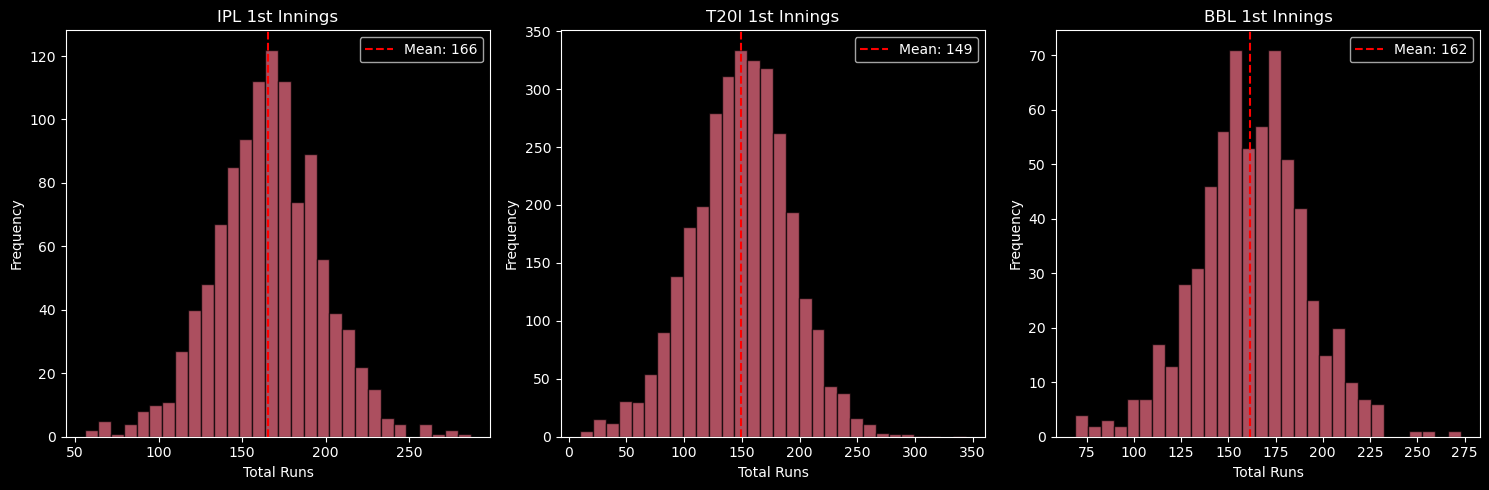

✅ Saved: charts/score_distributions.png


In [6]:
def get_first_innings_scores(deliveries_df, league_name):
    col_inning = 'inning' if 'inning' in deliveries_df.columns else 'innings'
    col_match_id = 'match_id' if 'match_id' in deliveries_df.columns else 'id'
    col_runs_total = 'runs_total' if 'runs_total' in deliveries_df.columns else 'total_runs'
    
    inn1 = deliveries_df[deliveries_df[col_inning] == 1].copy()
    scores = inn1.groupby(col_match_id).agg(total_runs=(col_runs_total, 'sum')).reset_index()
    print(f'\n{league_name} 1st Innings Scores:')
    print(f'  Mean:   {scores["total_runs"].mean():.1f}')
    print(f'  Median: {scores["total_runs"].median():.1f}')
    print(f'  Min:    {scores["total_runs"].min():.0f}')
    print(f'  Max:    {scores["total_runs"].max():.0f}')
    print(f'  Std:    {scores["total_runs"].std():.1f}')
    return scores

ipl_scores = get_first_innings_scores(ipl_deliveries, 'IPL')
t20_scores = get_first_innings_scores(t20_deliveries, 'T20I')
bbl_scores = get_first_innings_scores(bbl_deliveries, 'BBL')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, scores, name in zip(axes, [ipl_scores, t20_scores, bbl_scores], ['IPL', 'T20I', 'BBL']):
    ax.hist(scores['total_runs'], bins=30, edgecolor='black', alpha=0.7)
    ax.set_title(f'{name} 1st Innings')
    ax.set_xlabel('Total Runs')
    ax.set_ylabel('Frequency')
    ax.axvline(scores['total_runs'].mean(), color='red', linestyle='--', label=f'Mean: {scores["total_runs"].mean():.0f}')
    ax.legend()
plt.tight_layout()
os.makedirs('charts', exist_ok=True)
plt.savefig('charts/score_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: charts/score_distributions.png')

## 1.5 Data Quality Issues

In [7]:
print('=== DATA QUALITY REPORT ===\n')

for name, matches in [('IPL', ipl_matches), ('T20I', t20_matches), ('BBL', bbl_matches)]:
    print(f'--- {name} ---')
    print(f'Total matches: {len(matches)}')
    no_result = matches[matches['winner'].isna()]
    print(f'No result/abandoned: {len(no_result)}')
    dls = matches[matches['method'].notna()] if 'method' in matches.columns else []
    print(f'DLS affected: {len(dls)}')
    seasons = matches['season'].nunique()
    print(f'Seasons covered: {seasons}')
    print(f'Seasons: {sorted(matches["season"].unique())}')
    print()

=== DATA QUALITY REPORT ===

--- IPL ---
Total matches: 1095
No result/abandoned: 5
DLS affected: 21
Seasons covered: 17
Seasons: ['2007/08', '2009', '2009/10', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020/21', '2021', '2022', '2023', '2024']

--- T20I ---
Total matches: 3111
No result/abandoned: 0
DLS affected: 109
Seasons covered: 43
Seasons: ['2004/05', '2005', '2005/06', '2006', '2006/07', '2007', '2007/08', '2008', '2008/09', '2009', '2009/10', '2010', '2010/11', '2011', '2011/12', '2012', '2012/13', '2013', '2013/14', '2014', '2014/15', '2015', '2015/16', '2016', '2016/17', '2017', '2017/18', '2018', '2018/19', '2019', '2019/20', '2020', '2020/21', '2021', '2021/22', '2022', '2022/23', '2023', '2023/24', '2024', '2024/25', '2025', '2025/26']

--- BBL ---
Total matches: 647
No result/abandoned: 0
DLS affected: 32
Seasons covered: 15
Seasons: ['2011/12', '2012/13', '2013/14', '2014/15', '2015/16', '2016/17', '2017/18', '2018/19', '2019/20', '2020/21

## 1.6 Save Feature Statistics

In [8]:
feature_stats = {
    'ipl': {
        'avg_first_innings': float(ipl_scores['total_runs'].mean()),
        'chasing_win_rate': float(ipl_chase_rate),
        'total_matches': len(ipl_matches),
        'total_deliveries': len(ipl_deliveries)
    },
    't20i': {
        'avg_first_innings': float(t20_scores['total_runs'].mean()),
        'chasing_win_rate': float(t20_chase_rate),
        'total_matches': len(t20_matches),
        'total_deliveries': len(t20_deliveries)
    },
    'bbl': {
        'avg_first_innings': float(bbl_scores['total_runs'].mean()),
        'chasing_win_rate': float(bbl_chase_rate),
        'total_matches': len(bbl_matches),
        'total_deliveries': len(bbl_deliveries)
    }
}

os.makedirs('data/processed', exist_ok=True)
with open('data/processed/feature_stats.json', 'w') as f:
    json.dump(feature_stats, f, indent=2)

print('✅ Saved: data/processed/feature_stats.json')
print(json.dumps(feature_stats, indent=2))

✅ Saved: data/processed/feature_stats.json
{
  "ipl": {
    "avg_first_innings": 165.54703196347032,
    "chasing_win_rate": 0.5402930402930403,
    "total_matches": 1095,
    "total_deliveries": 260920
  },
  "t20i": {
    "avg_first_innings": 149.15396978463517,
    "chasing_win_rate": 0.5067524115755627,
    "total_matches": 3111,
    "total_deliveries": 711581
  },
  "bbl": {
    "avg_first_innings": 161.63833075734158,
    "chasing_win_rate": 0.527047913446677,
    "total_matches": 647,
    "total_deliveries": 151331
  }
}
